In [9]:
import os
os.getcwd()


'C:\\Users\\MTECH01'

In [10]:
import os
os.listdir()


['.anaconda',
 '.conda',
 '.continuum',
 '.icm',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jdks',
 '.jupyter',
 '.matplotlib',
 '.mgltools',
 '.pymol',
 '.pymoltimestamp',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'chemaxon',
 'Contacts',
 'Cookies',
 'deg_gene-ids.txt',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'IdeaProjects',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'Oryza_sativa.IRGSP-1.0.cds.all.fa',
 'Oryza_sativa.IRGSP-1.0.pep.all.fa',
 'Pictures',
 'prediction_results.txt',
 'PrintHood',
 'processed_entries.fasta',
 'promoters.fa',
 'Recent',
 'rice.fa',
 'rice.gtf',
 'Rice_DEG_with_I

In [11]:
#import libraries
!pip install biopython
from Bio import SeqIO
import pandas as pd
import os


In [15]:
df.shape


NameError: name 'df' is not defined

In [2]:
from Bio import SeqIO
import pandas as pd

In [3]:
#load promoter
promoter_dict={}

for record in  SeqIO.parse("promoters.fa", "fasta"):
    promoter_dict[record.id]=str(record.seq).upper()
print("Promoter loaded:", len(promoter_dict))

Promoter loaded: 38957


In [4]:
#load CDS
cds_dict={}

for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.cds.all.fa", "fasta"):
    cds_dict[record.id]=str(record.seq).upper()
print("CDS loaded:", len(cds_dict))

CDS loaded: 42582


In [5]:
#load protein

pep_dict={}

for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.pep.all.fa", "fasta"):
    description = record.description
    
    # extract transcript ID from description
    transcript_id = None
    
    for field in description.split():
        if field.startswith("transcript:"):
            transcript_id = field.replace("transcript:", "")
            break
    
    if transcript_id:
        pep_dict[transcript_id] = str(record.seq).upper()

print("Proteins loaded:", len(pep_dict))
    

Proteins loaded: 42582


In [6]:
#now verify ID matching
# check if first 5 CDS IDs exist in pep_dict
for i, gene in enumerate(cds_dict.keys()):
    print(gene, "→", gene in pep_dict)
    if i == 4:
        break


transcript-rps2 → True
transcript-petB → True
transcript-ndhB-2 → True
transcript-rpl36 → True
transcript-rpoC1 → True


In [7]:
def gc_content(seq):
    if len(seq) == 0:
        return 0
    return (seq.count("G") + seq.count("C")) / len(seq)

def count_motif(seq, motif):
    return seq.count(motif)

def cysteine_count(seq):
    return seq.count("C")

data = []

for gene in cds_dict.keys():
    
    prom = promoter_dict.get(gene, "")
    cds = cds_dict.get(gene, "")
    pep = pep_dict.get(gene, "")
    
    row = {
        "GeneID": gene,
        "Promoter_GC": gc_content(prom),
        "Wbox_count": count_motif(prom, "TTGACC"),
        "GCC_box_count": count_motif(prom, "AGCCGCC"),
        "CDS_length": len(cds),
        "CDS_GC": gc_content(cds),
        "Protein_length": len(pep),
        "Cys_count": cysteine_count(pep)
    }
    
    data.append(row)

df = pd.DataFrame(data)

df.head()


,GeneID,Promoter_GC,Wbox_count,GCC_box_count,CDS_length,CDS_GC,Protein_length,Cys_count
0,transcript-rps2,0,0,0,711,0.378340,236,5
1,transcript-petB,0,0,0,6,0.333333,2,0
2,transcript-ndhB-2,0,0,0,777,0.374517,259,7
3,transcript-rpl36,0,0,0,114,0.377193,37,3
4,transcript-rpoC1,0,0,0,2049,0.392875,682,16


In [8]:
df["Protein_length"].describe()


count    42582.000000
mean       333.424170
std        251.171363
min          2.000000
25%        144.000000
50%        273.000000
75%        452.000000
max       5342.000000
Name: Protein_length, dtype: float64

In [9]:
# check if promoter exists for first few genes
for i, gene in enumerate(cds_dict.keys()):
    print(gene, "→", gene in promoter_dict)
    if i == 4:
        break


transcript-rps2 → False
transcript-petB → False
transcript-ndhB-2 → False
transcript-rpl36 → False
transcript-rpoC1 → False


In [10]:
for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.cds.all.fa", "fasta"):
    print(record.description)
    break


transcript-rps2 cds chromosome:IRGSP-1.0:Pt:29540:30250:1 gene:gene-rps2 gene_biotype:protein_coding transcript_biotype:protein_coding gene_symbol:rps2 description:30S ribosomal protein S2 [Source:NCBI gene (formerly Entrezgene);Acc:3131442]


In [11]:
for i, k in enumerate(promoter_dict.keys()):
    print(k)
    if i == 5:
        break


1::1:181073-182073
1::1:14453629-14454629
1::1:18688347-18689347
1::1:24372569-24373569
1::1:30106879-30107879
1::1:31522662-31523662


In [12]:
#regenerating promoters using the GTF annotation file 
#extract 1kp upstream of each gene 
#label FASTA header using gene ID 


In [13]:
#first load rice.fa
from Bio import SeqIO

genome = {}

for record in SeqIO.parse("rice.fa", "fasta"):
    genome[record.id] = str(record.seq).upper()

print("Chromosomes loaded:", len(genome))
print("Chromosome names:", list(genome.keys())[:5])


Chromosomes loaded: 63
Chromosome names: ['1', 'Mt', 'Pt', '2', '3']


In [14]:
#parsing gtf file 
genes = []

with open("rice.gtf") as f:
    for line in f:
        if line.startswith("#"):
            continue
        
        fields = line.strip().split("\t")
        
        if len(fields) < 9:
            continue
        
        if fields[2] == "gene":
            
            chrom = fields[0]
            start = int(fields[3])
            end = int(fields[4])
            strand = fields[6]
            attributes = fields[8]
            
            # extract gene_id
            gene_id = None
            for attr in attributes.split(";"):
                attr = attr.strip()
                if attr.startswith("gene_id"):
                    gene_id = attr.split('"')[1]
                    break
            
            if gene_id:
                genes.append((gene_id, chrom, start, end, strand))

print("Total genes parsed:", len(genes))
print("Example:", genes[:3])


Total genes parsed: 38993
Example: [('ENSRNA049442722', '1', 182074, 182154, '+'), ('ENSRNA049442424', '1', 14454630, 14454702, '+'), ('ENSRNA049442327', '1', 18689348, 18689419, '+')]


In [15]:
#extract promoter again in python
promoters = {}

for gene_id, chrom, start, end, strand in genes:
    
    if chrom not in genome:
        continue
    
    if strand == "+":
        prom_start = max(0, start - 1001)
        prom_end = start - 1
        seq = genome[chrom][prom_start:prom_end]
        
    else:  # minus strand
        prom_start = end
        prom_end = end + 1000
        seq = genome[chrom][prom_start:prom_end]
        
        # reverse complement
        complement = str.maketrans("ATGCN", "TACGN")
        seq = seq.translate(complement)[::-1]
    
    if len(seq) == 1000:
        promoters[gene_id] = seq

print("Promoters extracted:", len(promoters))


Promoters extracted: 38991


In [68]:
#to make all the files to be used have gene ids and not transcript ids like in the case of cdsfile and protein file 

In [69]:
#first we will extract gene ids form  cds file (which are not the first thing in the header line tho)
#>Os06t0608300-01 cds chromosome:... gene:Os06g0608300
#we want Os06g0608300 not transcript id


In [16]:

from Bio import SeqIO
cds_gene_dict = {}
for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.cds.all.fa", "fasta"):
    desc = record.description
    gene_id = None
    for field in desc.split():
        if field.startswith("gene:"):
            gene_id = field.replace("gene:", "")
            break    
   
    if gene_id:
        cds_gene_dict[gene_id] = str(record.seq).upper()

print("Gene-level CDS:", len(cds_gene_dict))


Gene-level CDS: 35804


In [17]:
#restrciting to protein coing genes only cuz some genes do not have cds 
#build gene level priority dictionary
from Bio import SeqIO

pep_gene_dict = {}

for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.pep.all.fa", "fasta"):
    
    desc = record.description
    gene_id = None
    
    for field in desc.split():
        if field.startswith("gene:"):
            gene_id = field.replace("gene:", "")
            break
    
    if gene_id:
        pep_gene_dict[gene_id] = str(record.seq).upper()

print("Gene-level proteins:", len(pep_gene_dict))


Gene-level proteins: 35804


In [18]:
#build intersection
common_genes = (
    set(promoters.keys()) &
    set(cds_gene_dict.keys()) &
    set(pep_gene_dict.keys())
)

print("Final usable genes:", len(common_genes))


Final usable genes: 35803


In [19]:
#feature matrix final
import pandas as pd

def gc_content(seq):
    if len(seq) == 0:
        return 0
    return (seq.count("G") + seq.count("C")) / len(seq)

def count_motif(seq, motif):
    return seq.count(motif)

def cysteine_count(seq):
    return seq.count("C")

data = []

for gene in common_genes:
    
    prom = promoters[gene]
    cds = cds_gene_dict[gene]
    pep = pep_gene_dict[gene]
    
    row = {
        "GeneID": gene,
        "Promoter_GC": gc_content(prom),
        "Wbox_count": count_motif(prom, "TTGACC"),
        "GCC_box_count": count_motif(prom, "AGCCGCC"),
        "CDS_length": len(cds),
        "CDS_GC": gc_content(cds),
        "Protein_length": len(pep),
        "Cys_count": cysteine_count(pep)
    }
    
    data.append(row)

df = pd.DataFrame(data)

print("Final dataset shape:", df.shape)
df.head()


Final dataset shape: (35803, 8)


,GeneID,Promoter_GC,Wbox_count,GCC_box_count,CDS_length,CDS_GC,Protein_length,Cys_count
0,Os01g0861000,0.435,0,0,333,0.717718,110,1
1,Os01g0618700,0.594,0,0,795,0.739623,264,3
2,Os10g0559200,0.392,1,0,603,0.484245,200,7
3,Os10g0552800,0.366,0,0,399,0.694236,132,11
4,Os01g0834400,0.349,0,0,354,0.601695,117,2


In [20]:
df.describe()


,Promoter_GC,Wbox_count,GCC_box_count,CDS_length,CDS_GC,Protein_length,Cys_count
count,35803.000000,35803.000000,35803.000000,35803.000000,35803.000000,35803.000000,35803.000000
mean,0.423144,0.220317,0.075692,973.716839,0.574830,323.604502,6.224199
std,0.080034,0.485190,0.304926,747.626701,0.106451,249.197777,6.109048
min,0.000000,0.000000,0.000000,6.000000,0.161905,2.000000,0.000000
25%,0.366000,0.000000,0.000000,417.000000,0.481481,138.000000,2.000000
50%,0.407000,0.000000,0.000000,780.000000,0.571930,259.000000,5.000000
75%,0.466000,0.000000,0.000000,1323.000000,0.671904,440.000000,8.000000
max,0.764000,5.000000,7.000000,16029.000000,0.910314,5342.000000,145.000000


In [21]:
df.isnull().sum()


GeneID            0
Promoter_GC       0
Wbox_count        0
GCC_box_count     0
CDS_length        0
CDS_GC            0
Protein_length    0
Cys_count         0
dtype: int64

In [22]:
# we are dropping the CDS _length cuz ist same as protein lenght in some way 
df = df.drop(columns=["CDS_length"])


In [23]:
#adding cys_frequency in feature list 
df["Cys_frequency"] = df["Cys_count"] / df["Protein_length"]


In [24]:
#quick correlation check between protein lenghth , cys count and cds lenghth 
df[["Cys_count", "Cys_frequency", "Protein_length"]].corr()


,Cys_count,Cys_frequency,Protein_length
Cys_count,1.000000,0.409385,0.712337
Cys_frequency,0.409385,1.000000,-0.142304
Protein_length,0.712337,-0.142304,1.000000


In [25]:
# ADD LABEL COLUMNS
df.columns


Index(['GeneID', 'Promoter_GC', 'Wbox_count', 'GCC_box_count', 'CDS_GC',
       'Protein_length', 'Cys_count', 'Cys_frequency'],
      dtype='object')

In [26]:
deg_df= pd.read_csv("Rice_deg_with_ID.csv")

In [27]:
deg_list= deg_df["GeneID"].tolist()

In [28]:
#create label
df["Label"] = 0
df.loc[df["GeneID"].isin(deg_list), "Label"] = 1




In [29]:
print(df["Label"].value_counts())


Label
0    35417
1      386
Name: count, dtype: int64


In [30]:
#here we are getting 384 instead of 394 which means some degs are ,missisng in the feature table os we'll check 
print("Total DEGs in list:", len(deg_list))
print("DEGs matched in df:", df["Label"].sum())


Total DEGs in list: 394
DEGs matched in df: 386


In [31]:
#the above tells some degs are mismatched so lets see which are those
missing = set(deg_list) - set(df["GeneID"])
print("Missing DEGs:", len(missing))
print(list(missing)[:10])


Missing DEGs: 8
['Os05g0573550', 'Os01g0373800', 'ENSRNA049467377', 'Os02g0508650', 'ENSRNA049464535', 'ENSRNA049476493', 'Os05g0261001', 'Os08g0406150']


In [32]:
#check what ID sysytem your df uses 
df["GeneID"].head(20)


0     Os01g0861000
1     Os01g0618700
2     Os10g0559200
3     Os10g0552800
4     Os01g0834400
5     Os11g0428150
6     Os03g0243700
7     Os08g0125200
8     Os08g0430300
9     Os03g0728200
10    Os11g0484000
11    Os03g0845800
12    Os01g0369950
13    Os07g0406600
14    Os01g0697700
15    Os03g0356400
16    Os05g0488000
17    Os02g0608500
18    Os09g0549600
19    Os07g0639500
Name: GeneID, dtype: object

In [33]:
print("Final positives:", df["Label"].sum())
print("Final background:", (df["Label"] == 0).sum())


Final positives: 386
Final background: 35417


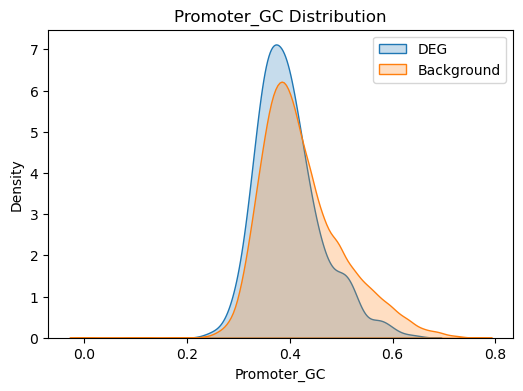

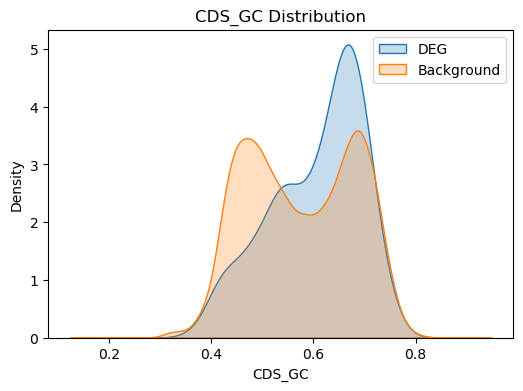

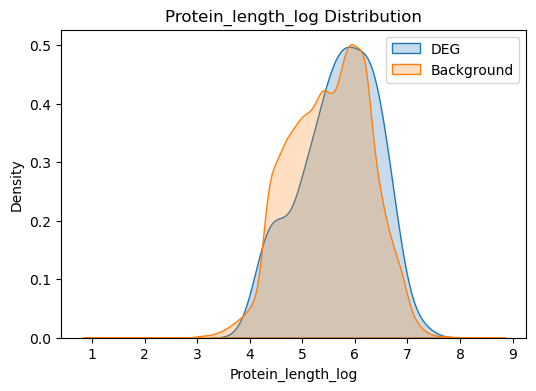

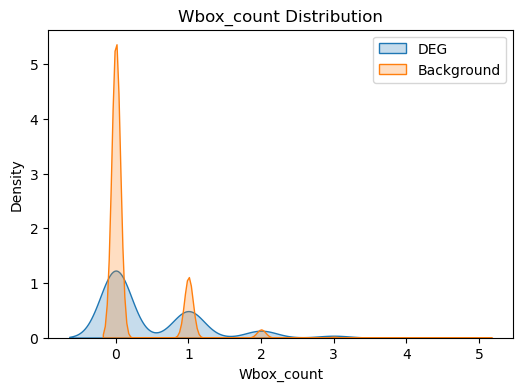

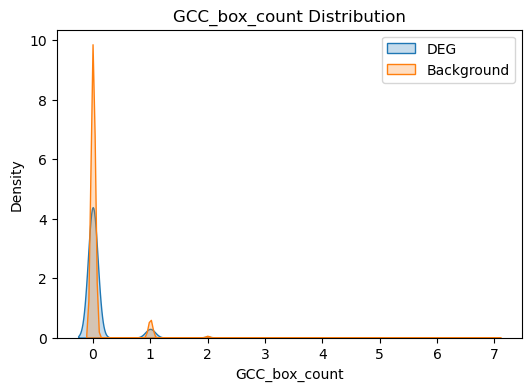

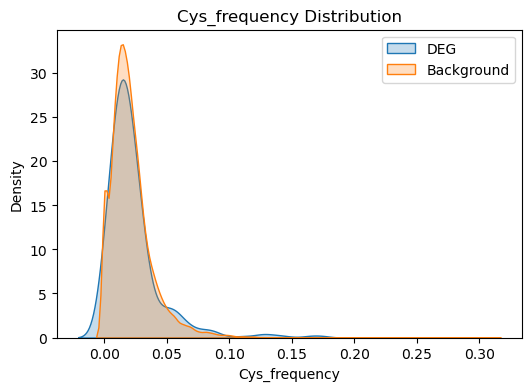

In [34]:
import numpy as np

df["Protein_length_log"] = np.log1p(df["Protein_length"])


#KDE distribution
import seaborn as sns
import matplotlib.pyplot as plt

P_indices = df[df["Label"] == 1].index
U_indices = df[df["Label"] == 0].index

features = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Wbox_count",
    "GCC_box_count",
    "Cys_frequency"
]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df.loc[P_indices, feature], label="DEG", fill=True)
    sns.kdeplot(df.loc[U_indices, feature], label="Background", fill=True)
    plt.title(f"{feature} Distribution")
    plt.legend()
    plt.show()


In [35]:
#now do sanity and oob test 
#define indecies again for precaution 
P_indices = df[df["Label"] == 1].index
U_indices = df[df["Label"] == 0].index

print("Positives:", len(P_indices))
print("Background:", len(U_indices))


Positives: 386
Background: 35417


In [36]:
#define feature matrix do not include geneID and label only numaerical features for the test we need that's why 
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Wbox_count",
    "GCC_box_count",
    "Cys_frequency"
]


In [37]:
#balaced sampling + Rf
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Sample temporary negatives
U_sample = np.random.choice(U_indices, size=len(P_indices), replace=False)

# Build training set
X_temp = pd.concat([
    df.loc[P_indices, feature_cols],
    df.loc[U_sample, feature_cols]
])

y_temp = [1]*len(P_indices) + [0]*len(P_indices)

# Train RF
clf = RandomForestClassifier(
    n_estimators=500,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)   

clf.fit(X_temp, y_temp)

print("OOB Score:", clf.oob_score_)


OOB Score: 0.6398963730569949


In [38]:
#10X STABILITY RUN where negatives are randomly sampled
#also get the importance list of the feature 
scores = []
importance_list = []

for i in range(10):
    U_sample = np.random.choice(U_indices, size=len(P_indices), replace=False)

    X_temp = pd.concat([
        df.loc[P_indices, feature_cols],
        df.loc[U_sample, feature_cols]
    ])

    y_temp = [1]*len(P_indices) + [0]*len(P_indices)

    clf = RandomForestClassifier(
        n_estimators=300,
        oob_score=True,
        random_state=i,
        n_jobs=-1
    )

    clf.fit(X_temp, y_temp)

    scores.append(clf.oob_score_)
    importance_list.append(clf.feature_importances_)

print("Mean OOB:", np.mean(scores))
print("Std OOB:", np.std(scores))


Mean OOB: 0.6389896373056995
Std OOB: 0.02212752219104351


In [39]:
#computing average feature importance 
# Convert to numpy array
importance_array = np.array(importance_list)

# Mean + Std across runs
mean_importance = np.mean(importance_array, axis=0)
std_importance = np.std(importance_array, axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean Importance": mean_importance,
    "Std": std_importance
}).sort_values("Mean Importance", ascending=False)

print(importance_df)


              Feature  Mean Importance       Std
1              CDS_GC         0.265718  0.012709
2  Protein_length_log         0.235514  0.006488
0         Promoter_GC         0.230656  0.009988
5       Cys_frequency         0.204757  0.007091
3          Wbox_count         0.050438  0.004215
4       GCC_box_count         0.012917  0.001035


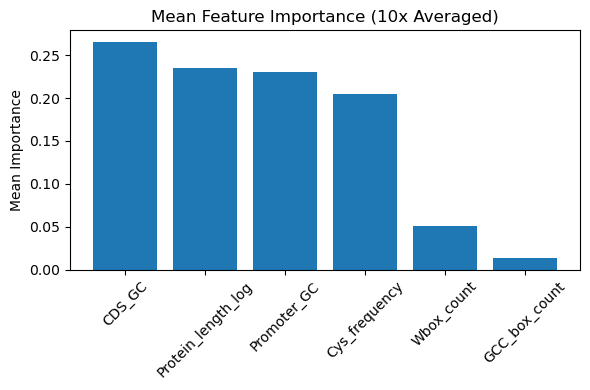

In [40]:
#visualize it 
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(importance_df["Feature"], importance_df["Mean Importance"])
plt.xticks(rotation=45)
plt.ylabel("Mean Importance")
plt.title("Mean Feature Importance (10x Averaged)")
plt.tight_layout()
plt.show()


In [41]:
#remove GCC_box_OCUNT CUZ IT IS NOT REALLY HAVING ANY EFFECT ACC TO THE PLOT ABOVE 
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Wbox_count",
    "Cys_frequency"
]


In [42]:
#re-run 10x stability 
scores = []
importance_list = []

for i in range(10):
    U_sample = np.random.choice(U_indices, size=len(P_indices), replace=False)

    X_temp = pd.concat([
        df.loc[P_indices, feature_cols],
        df.loc[U_sample, feature_cols]
    ])

    y_temp = [1]*len(P_indices) + [0]*len(P_indices)

    clf = RandomForestClassifier(
        n_estimators=300,
        oob_score=True,
        random_state=i,
        n_jobs=-1
    )

    clf.fit(X_temp, y_temp)

    scores.append(clf.oob_score_)
    importance_list.append(clf.feature_importances_)

print("Mean OOB:", np.mean(scores))
print("Std OOB:", np.std(scores))


Mean OOB: 0.6484455958549222
Std OOB: 0.01644822712886008


In [ ]:
#even tho the mean oob changes the std is really good indicating the model in highly consisitent . the slight decraese in mean oob does not really makes a diff 
#also the diff btwn the old and the new oob is 0.006 which is less than 1 percent , prolly can be considered a s noise.


In [43]:
#but let's compute ne wavg importance 
importance_array = np.array(importance_list)

mean_importance = np.mean(importance_array, axis=0)
std_importance = np.std(importance_array, axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean Importance": mean_importance,
    "Std": std_importance
}).sort_values("Mean Importance", ascending=False)

print(importance_df)


              Feature  Mean Importance       Std
1              CDS_GC         0.277829  0.007132
2  Protein_length_log         0.236817  0.005709
0         Promoter_GC         0.229139  0.005451
4       Cys_frequency         0.205901  0.003577
3          Wbox_count         0.050315  0.002974


In [ ]:
#slight increase in importance than before 


In [44]:
df.columns

Index(['GeneID', 'Promoter_GC', 'Wbox_count', 'GCC_box_count', 'CDS_GC',
       'Protein_length', 'Cys_count', 'Cys_frequency', 'Label',
       'Protein_length_log'],
      dtype='object')

In [82]:
#add local biochemial features 
from Bio import SeqIO

protein_dict = {}

for record in SeqIO.parse("rice_proteins.fasta", "fasta"):
    gene_id = record.id.split()[0]
    protein_dict[gene_id] = str(record.seq)

print("Total proteins loaded:", len(protein_dict))


FileNotFoundError: [Errno 2] No such file or directory: 'rice_proteins.fasta'

In [45]:
import os
print(os.getcwd())


C:\Users\MTECH01


In [46]:
print(os.listdir())


['.anaconda', '.conda', '.continuum', '.icm', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.matplotlib', '.mgltools', '.pymol', '.pymoltimestamp', '.RDataTmp', '.Rhistory', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'cds_list.txt', 'chemaxon', 'Contacts', 'Cookies', 'deg_gene-ids.txt', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Gene_Intersection_Venn.png', 'IdeaProjects', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'Oryza_sativa.IRGSP-1.0.cds.all.fa', 'Oryza_sativa.IRGSP-1.0.pep.all.fa', 'pep_list.txt', 'Pictures', 'prediction_results.txt', 'PrintHood', 'processed_entries.fasta', 'promoters.fa', 'promoter

In [47]:
from Bio import SeqIO

protein_dict = {}

for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.pep.all.fa", "fasta"):
    gene_id = record.id.split()[0]
    protein_dict[gene_id] = str(record.seq)

print("Total proteins loaded:", len(protein_dict))



Total proteins loaded: 42582


In [48]:
#compute Pi and GRAVY
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Initialize columns
df["pI"] = None
df["GRAVY"] = None
df["Leu_frequency"] = None
df["Pro_frequency"] = None
df["Tyr_frequency"] = None

for idx, row in df.iterrows():
    gene = row["GeneID"]
    
    if gene in protein_dict:
        seq = protein_dict[gene]
        
        if len(seq) > 0:
            analysed = ProteinAnalysis(seq)
            
            df.at[idx, "pI"] = analysed.isoelectric_point()
            df.at[idx, "GRAVY"] = analysed.gravy()
            
            aa_freq = analysed.get_amino_acids_percent()
            
            df.at[idx, "Leu_frequency"] = aa_freq.get("L", 0)
            df.at[idx, "Pro_frequency"] = aa_freq.get("P", 0)
            df.at[idx, "Tyr_frequency"] = aa_freq.get("Y", 0)

print("Feature addition complete.")


Feature addition complete.


In [49]:
#CHECK MISSING VALUES
df[["pI","GRAVY","Leu_frequency","Pro_frequency","Tyr_frequency"]].isnull().sum()


pI               35803
GRAVY            35803
Leu_frequency    35803
Pro_frequency    35803
Tyr_frequency    35803
dtype: int64

In [ ]:
#okay we got so many nulls that means the gene ids did not match with the protein_dict maybebcs they awere in different format 

In [50]:
#lets inspect fasta id format 
# show first 10 protein_dict keys
list(protein_dict.keys())[:10]


['cds-CAA33989.1',
 'cds-CAA33977.1',
 'cds-CAA33920.1',
 'cds-CAA33981.1',
 'cds-CAA33987.1',
 'cds-CAA33967.1',
 'cds-CAA33941.1',
 'cds-CAA34007.1',
 'cds-CAA34014.1',
 'cds-CAA33980.1']

In [ ]:
# yeah so basically they are in different format acc to the output..basically annotation inconsistency problem
#but heres the catch as we scroll down the pep file in notepad we find the transcript ids with the same geneid format except that it has isoform number also in it so we just gene to extract the gene id smartly 

In [51]:
from Bio import SeqIO

protein_dict = {}

for record in SeqIO.parse("Oryza_sativa.IRGSP-1.0.pep.all.fa", "fasta"):
    header = record.description
    
    # Extract gene ID from header
    gene_id = header.split("gene:")[1].split()[0]
    
    protein_dict[gene_id] = str(record.seq)

print("Total proteins mapped:", len(protein_dict))


Total proteins mapped: 35804


In [52]:
#confirm all new features exist
df.columns

Index(['GeneID', 'Promoter_GC', 'Wbox_count', 'GCC_box_count', 'CDS_GC',
       'Protein_length', 'Cys_count', 'Cys_frequency', 'Label',
       'Protein_length_log', 'pI', 'GRAVY', 'Leu_frequency', 'Pro_frequency',
       'Tyr_frequency'],
      dtype='object')

In [53]:
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Cys_frequency",
    "Wbox_count",
    "pI",
    "GRAVY",
    "Leu_frequency",
    "Pro_frequency",
    "Tyr_frequency"
]


In [55]:
#run 10x stability test agian with the new features added
#re-run 10x stability 
scores = []
importance_list = []

for i in range(10):
    U_sample = np.random.choice(U_indices, size=len(P_indices), replace=False)

    X_temp = pd.concat([
        df.loc[P_indices, feature_cols],
        df.loc[U_sample, feature_cols]
    ])

    y_temp = [1]*len(P_indices) + [0]*len(P_indices)

    clf = RandomForestClassifier(
        n_estimators=300,
        oob_score=True,
        random_state=i,
        n_jobs=-1
    )

    clf.fit(X_temp, y_temp)

    scores.append(clf.oob_score_)
    importance_list.append(clf.feature_importances_)

print("Mean OOB:", np.mean(scores))
print("Std OOB:", np.std(scores))


Mean OOB: 0.6573834196891191
Std OOB: 0.015362170040596403


In [ ]:
#okay so adding grvy,pi, leu, pro, tyr did not improve performance...that man these features give weak signals ...so Core genomic features carry more signal than general physicochemical properties.

In [56]:
#so strongest predictors are 
##CDS_GC
##Protein_length_log
##Promoter_GC
##Cys_frequency
##Wbox_count
#that gave oob of 0.64


In [57]:
#so now well go back to thses strong faetures and re run oob to confirm their importance if gives back again 0.064 oob
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Cys_frequency",
    "Wbox_count"
]


In [58]:
#re reun 10x
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

scores = []
importance_list = []

for i in range(10):
    U_sample = np.random.choice(U_indices, size=len(P_indices), replace=False)

    X_temp = pd.concat([
        df.loc[P_indices, feature_cols],
        df.loc[U_sample, feature_cols]
    ])

    y_temp = [1]*len(P_indices) + [0]*len(P_indices)

    clf = RandomForestClassifier(
        n_estimators=300,
        oob_score=True,
        random_state=i,
        n_jobs=-1
    )

    clf.fit(X_temp, y_temp)

    scores.append(clf.oob_score_)
    importance_list.append(clf.feature_importances_)

print("Mean OOB:", np.mean(scores))
print("Std OOB:", np.std(scores))


Mean OOB: 0.6374352331606218
Std OOB: 0.010190440111511358


In [59]:
#re analyse faeture importance
importance_array = np.array(importance_list)

mean_importance = np.mean(importance_array, axis=0)
std_importance = np.std(importance_array, axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean Importance": mean_importance,
    "Std": std_importance
}).sort_values("Mean Importance", ascending=False)

print(importance_df)


              Feature  Mean Importance       Std
1              CDS_GC         0.273637  0.011796
2  Protein_length_log         0.243476  0.006351
0         Promoter_GC         0.232481  0.011982
3       Cys_frequency         0.201881  0.004407
4          Wbox_count         0.048525  0.004502


In [60]:
#load prediction file
import pandas as pd

sp = pd.read_csv(
    "prediction_results.txt",
    sep="\t",
    comment="#",
    header=None
)

In [61]:
#assign column names
sp.columns = [
    "ID_full",
    "Prediction",
    "OTHER",
    "SP",
    "LIPO",
    "TAT",
    "TATLIPO",
    "PILIN",
    "CS_position"
]

In [62]:
#extract gene id
sp["GeneID"] = sp["ID_full"].str.extract(r'gene:(Os\d+g\d+)')

In [63]:
#create features
#binary features
sp["SignalP_binary"] = (sp["Prediction"] != "OTHER").astype(int)

In [64]:
#continous features
sp["SignalP_SP_prob"] = sp["SP"]

In [65]:
#after extraction...main feature engg
sp_clean = sp.dropna(subset=["GeneID"])

In [66]:
#merge
df = df.merge(
    sp_clean[["GeneID", "SignalP_binary", "SignalP_SP_prob"]],
    on="GeneID",
    how="left"
)

In [67]:
#sanity check after merge
print(df.shape)
print(df[["SignalP_binary","SignalP_SP_prob"]].isna().sum())
print(df["Label"].value_counts())

(42581, 17)
SignalP_binary     109
SignalP_SP_prob    230
dtype: int64
Label
0    42163
1      418
Name: count, dtype: int64


In [68]:
#why the numbers have chanegd 
#check duplicates 
df["GeneID"].nunique()

35803

In [69]:
#see we have 35803 unique genes and the rest are duplicates so we are save ....we just need to fix these duplcates 
#first confirm this 
df["GeneID"].value_counts().head(10)

GeneID
Os07g0182900    6
Os06g0113900    6
Os01g0120800    6
Os07g0424400    6
Os08g0564300    6
Os05g0481100    6
Os01g0563000    6
Os09g0502100    6
Os05g0591900    6
Os08g0203600    6
Name: count, dtype: int64

In [70]:
#so here one genes appears 6 times

In [71]:
#we craete one row per gene 
df = df.groupby("GeneID").agg({
    "Promoter_GC": "mean",
    "Wbox_count": "mean",
    "GCC_box_count": "mean",
    "CDS_GC": "mean",
    "Protein_length": "mean",
    "Cys_count": "mean",
    "Cys_frequency": "mean",
    "Protein_length_log": "mean",
    "SignalP_binary": "max",      # if any isoform secreted → gene secreted
    "SignalP_SP_prob": "max",     # strongest signal kept
    "Label": "max"                # preserve positive genes
}).reset_index()

In [72]:
#check
print(df.shape)
print(df["GeneID"].nunique())
print(df["Label"].value_counts())

(35803, 12)
35803
Label
0    35417
1      386
Name: count, dtype: int64


In [73]:
#separate p and u 
P = df[df["Label"] == 1]
U = df[df["Label"] == 0]

In [74]:
#define feature matrix
feature_cols = [
    "Promoter_GC",
    "Wbox_count",
    "GCC_box_count",
    "CDS_GC",
    "Protein_length", 
    "Cys_count",
    "Cys_frequency",
    "Protein_length_log",
    "SignalP_binary",
    "SignalP_SP_prob"
]

In [75]:
#pu bagging 10x or stability
import numpy as np
from sklearn.ensemble import RandomForestClassifier

n_runs = 10
all_probs = np.zeros((len(df), n_runs))

for i in range(n_runs):
    
    U_sample = U.sample(n=len(P), random_state=i)
    
    train_data = pd.concat([P, U_sample])
    
    X_train = train_data[feature_cols]
    y_train = train_data["Label"]
    
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=i
    )
    
    model.fit(X_train, y_train)
    
    all_probs[:, i] = model.predict_proba(df[feature_cols])[:, 1]

In [76]:
#compute stability score 
df["PU_score"] = all_probs.mean(axis=1)
df["PU_std"] = all_probs.std(axis=1)

In [77]:
#That’s a big separation.
#Your model is learning a decision boundary that distinguishes DEGs from background genes.
#we did mean scoring but itr alone does not tell about  separation so we need to run the code below. 

In [78]:
print(df[df["Label"]==1]["PU_score"].describe())
print(df[df["Label"]==0]["PU_score"].describe())
#look at the 25th, 75th and 50th percentile score 

count    386.000000
mean       0.853760
std        0.076174
min        0.658000
25%        0.796833
50%        0.859333
75%        0.915000
max        0.994000
Name: PU_score, dtype: float64
count    35417.000000
mean         0.399414
std          0.180416
min          0.037333
25%          0.255667
50%          0.373000
75%          0.522000
max          0.963000
Name: PU_score, dtype: float64


In [ ]:
#check
#Unlabeled max = 0.963. That means:Some unlabeled genes look more immune-like than some known positives.
#75% of positives are above 0.915. 75% of unlabeled are below 0.522
#This means your distributions are mostly separated.
#There is some overlap — that’s normal in biological systems.
#But this is not the “complete overlap disaster” scenario.

In [79]:
df[(df["Label"]==0) & (df["PU_score"] > 0.8)].shape

(808, 14)

In [80]:
#to see if the signalp+motif+cys frequency features are biologically meaningful
#run one balanced model w OOB enabled
model = RandomForestClassifier(
    n_estimators=500,
    oob_score=True,
    class_weight="balanced_subsample",
    random_state=42
)

In [122]:
model.oob_score_

AttributeError: 'RandomForestClassifier' object has no attribute 'oob_score_'

In [81]:
# Step 1: Create balanced training data
U_sample = U.sample(n=len(P), random_state=42)
train_data = pd.concat([P, U_sample])

X_train = train_data[feature_cols]
y_train = train_data["Label"]

# Step 2: Train model with OOB enabled
model = RandomForestClassifier(
    n_estimators=500,
    oob_score=True,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Step 3: Print OOB
print("OOB score:", model.oob_score_)

OOB score: 0.6917098445595855


In [127]:
#before we move forward ifeel the final usabl gne thing that we did initially needs visaulisation so we will generate a ven diagram
!pip install matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45437 sha256=e565b5d7982e93dbd014676bbb86ecd7dd24706ebd714be7c9f37382592f204c
  Stored in directory: c:\users\mtech01\appdata\local\pip\cache\wheels\d1\5f\e6\771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn


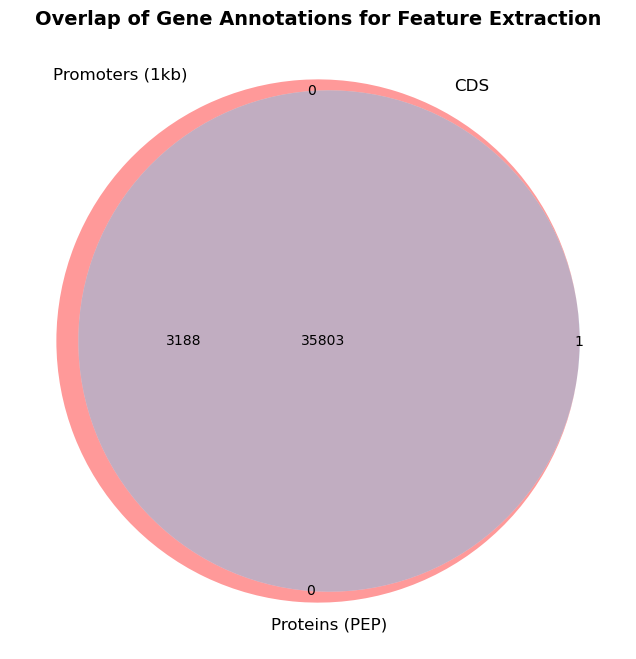

In [129]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Define your sets
set_promoters = set(promoters.keys())
set_cds = set(cds_gene_dict.keys())
set_pep = set(pep_gene_dict.keys())

# Create a figure
plt.figure(figsize=(8, 8))

# Draw the Venn diagram
v = venn3([set_promoters, set_cds, set_pep], 
          set_labels=('Promoters (1kb)', 'CDS', 'Proteins (PEP)'))

# Add a title
plt.title("Overlap of Gene Annotations for Feature Extraction", fontsize=14, fontweight='bold')

# Save it as a high-quality image for your thesis/tracker
plt.savefig("Gene_Intersection_Venn.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [82]:
#this looks ugly so we will do this in r to get prettier venn diagram
import pandas as pd

# Save the lists to text files
pd.Series(list(promoters.keys())).to_csv("promoters_list.txt", index=False, header=False)
pd.Series(list(cds_gene_dict.keys())).to_csv("cds_list.txt", index=False, header=False)
pd.Series(list(pep_gene_dict.keys())).to_csv("pep_list.txt", index=False, header=False)

print("Exported to txt files successfully!")

Exported to txt files successfully!


In [ ]:
#so basically i want to check wht if some of my positives are in that promoter only group in 3188 one.


In [83]:
#define promoter only group
#make the list as sets first
promoters_set = set(promoters)

In [84]:
cds_set = set(cds_gene_dict.keys())
pep_set = set(pep_gene_dict.keys())

In [85]:
promoter_only = promoters_set - (cds_set | pep_set)

print("Promoter-only genes:", len(promoter_only))

Promoter-only genes: 3188


In [135]:
#check lost positives
lost_positives = set(positive_genes) & promoter_only

print("Lost positive genes:", len(lost_positives))

NameError: name 'positive_genes' is not defined

In [86]:
promoters_set = set(promoters)

In [87]:
cds_set = set(cds_gene_dict.keys())
pep_set = set(pep_gene_dict.keys())

In [88]:
positive_genes = set(deg_list)


In [89]:
#define promoter only group
promoter_only = promoters_set - (cds_set | pep_set)

print("Promoter-only genes:", len(promoter_only))

Promoter-only genes: 3188


In [90]:
#check if u lost positive genes
lost_positives = positive_genes & promoter_only

print("Lost positive genes:", len(lost_positives))

Lost positive genes: 8


In [91]:
#check how many positives survived
usable_genes = promoters_set & cds_set & pep_set

retained_positives = positive_genes & usable_genes

print("Retained positive genes:", len(retained_positives))

Retained positive genes: 386


In [92]:
#check if signal p is diff btwn p and u 
pd.crosstab(df["SignalP_binary"], df["Label"], normalize="columns")

Label,0,1
SignalP_binary,,
0.0,0.906254,0.670984
1.0,0.093746,0.329016


In [93]:
#check p value
from scipy.stats import chi2_contingency

table = pd.crosstab(df["SignalP_binary"], df["Label"])
chi2, p, dof, exp = chi2_contingency(table)

print("p-value:", p)

p-value: 3.5960118243795393e-54


In [94]:
#see if it contributes predictive power
import pandas as pd

importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importances)

CDS_GC                0.190080
Promoter_GC           0.157157
SignalP_SP_prob       0.141654
Protein_length        0.119461
Protein_length_log    0.118245
Cys_frequency         0.115006
Cys_count             0.075660
Wbox_count            0.038351
SignalP_binary        0.036908
GCC_box_count         0.007478
dtype: float64


In [95]:
df = df[df["GeneID"].isin(common_genes)]


In [96]:
high_confidence = df[
    (df["Label"]==0) &
    (df["PU_score"] > 0.8)
]

print(len(high_confidence))

808


In [97]:
#feature importance after signal p addition
model.feature_importances_

array([0.15715682, 0.03835114, 0.0074784 , 0.19007991, 0.11946104,
       0.07566003, 0.11500565, 0.11824507, 0.03690792, 0.14165403])

In [98]:
#continuingw the feature exploration we will add protein cyst count 
#feature promoter at content
df["Promoter_AT"] = 1 - df["Promoter_GC"]

In [99]:
df["Small_protein"] = (df["Protein_length"] < 300).astype(int)

In [100]:
#signal peptide confidence
df["SignalP_confidence"] = df["SignalP_binary"] * df["SignalP_SP_prob"]

In [101]:
#scaled cystein density
df["Cys_density_scaled"] = df["Cys_frequency"] * df["Protein_length"]

In [102]:
#promoter moif density
df["Motif_density"] = (df["Wbox_count"] + df["GCC_box_count"]) / 1000

In [103]:
df[[
"Promoter_AT",
"Small_protein",
"SignalP_confidence",
"Cys_density_scaled",
"Motif_density"
]].describe()

,Promoter_AT,Small_protein,SignalP_confidence,Cys_density_scaled,Motif_density
count,35803.000000,35803.000000,35586.000000,35803.000000,35803.000000
mean,0.576856,0.561126,0.087393,6.224199,0.000296
std,0.080034,0.496256,0.277163,6.109048,0.000569
min,0.236000,0.000000,0.000000,0.000000,0.000000
25%,0.534000,0.000000,0.000000,2.000000,0.000000
50%,0.593000,1.000000,0.000000,5.000000,0.000000
75%,0.634000,1.000000,0.000000,8.000000,0.000000
max,1.000000,1.000000,0.999291,145.000000,0.007000


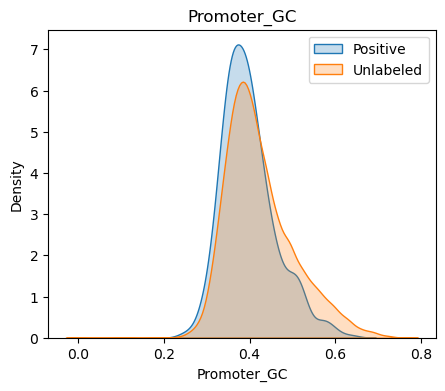

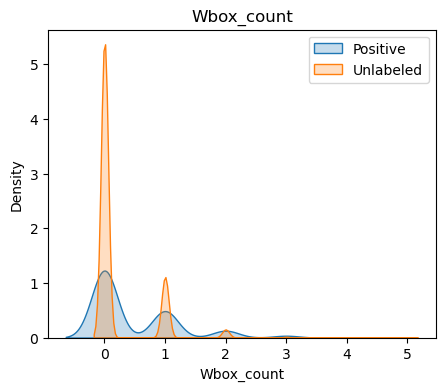

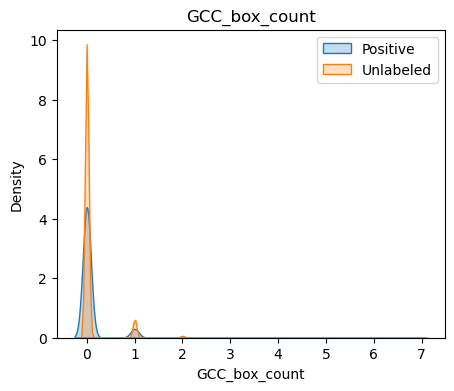

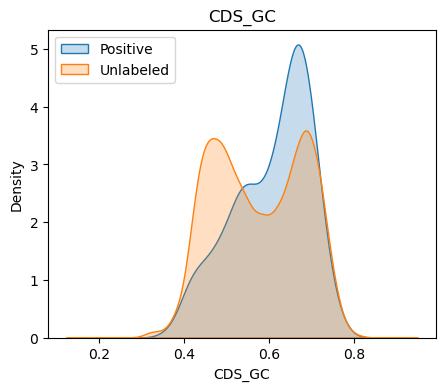

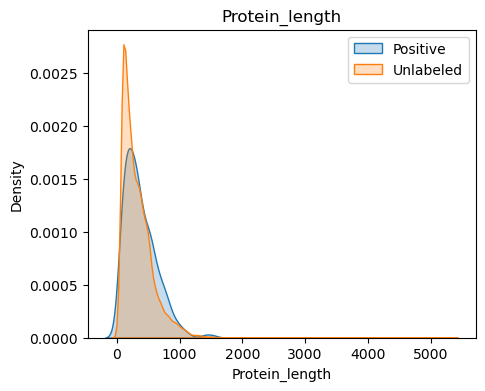

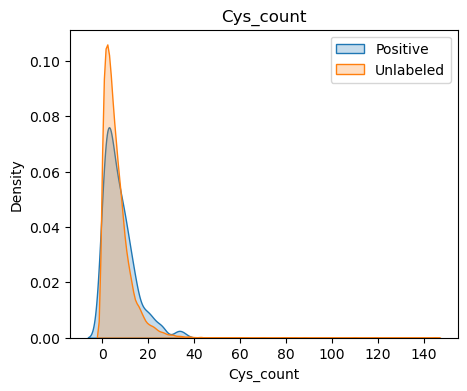

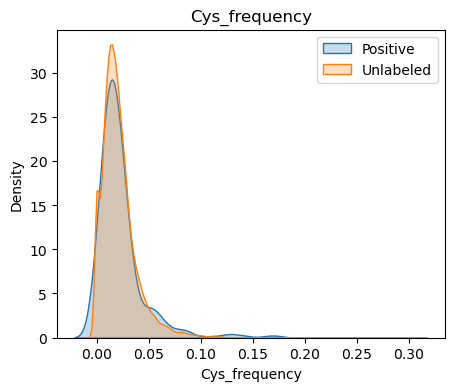

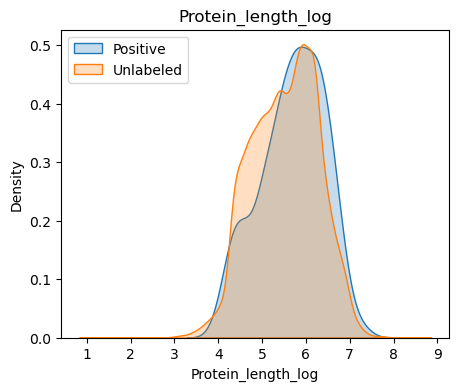

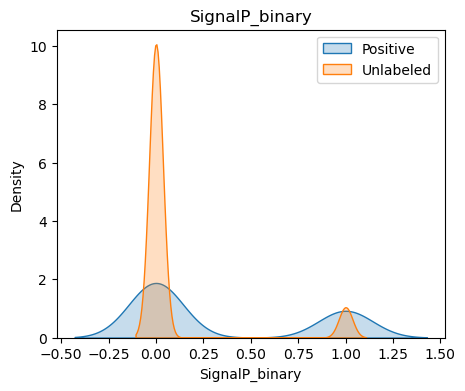

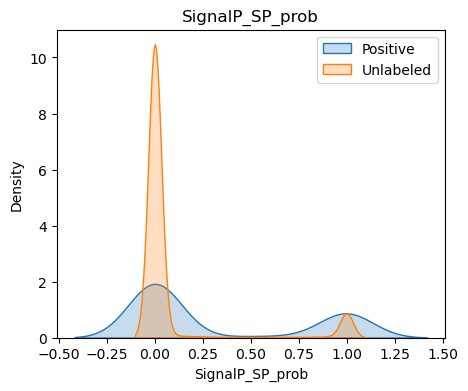

In [104]:
#distribution check
#Do immune genes actually look different from the rest?
import seaborn as sns
import matplotlib.pyplot as plt

for col in feature_cols:
    plt.figure(figsize=(5,4))
    sns.kdeplot(df[df["Label"]==1][col], label="Positive", fill=True)
    sns.kdeplot(df[df["Label"]==0][col], label="Unlabeled", fill=True)
    plt.title(col)
    plt.legend()
    plt.show()

In [105]:
#doing mann whitney u test 
from scipy.stats import mannwhitneyu

for col in feature_cols:
    pos = df[df["Label"]==1][col]
    unl = df[df["Label"]==0][col]

    stat, p = mannwhitneyu(pos, unl)

    print(col, "p-value:", p)

Promoter_GC p-value: 3.2060260940110713e-10
Wbox_count p-value: 9.47108052380827e-16
GCC_box_count p-value: 0.9708207226368438
CDS_GC p-value: 3.581364973530931e-08
Protein_length p-value: 6.649373706960903e-06
Cys_count p-value: 0.00011031671673151174
Cys_frequency p-value: 0.7335613240018308
Protein_length_log p-value: 6.653406836423378e-06
SignalP_binary p-value: nan
SignalP_SP_prob p-value: nan


In [111]:
#effect size
import numpy as np

for col in feature_cols:
    pos = df[df["Label"]==1][col]
    unl = df[df["Label"]==0][col]

    effect = np.mean(pos) - np.mean(unl)

    print(col, "effect size:", effect)

Promoter_GC effect size: -0.026020170928717334
Wbox_count effect size: 0.23035328457499918
GCC_box_count effect size: -0.003187486001350895
CDS_GC effect size: 0.030801668815044647
Protein_length effect size: 49.88670497365143
Cys_count effect size: 1.328989137706622
Cys_frequency effect size: 0.0015590678999618489
Protein_length_log effect size: 0.16958362108545977
SignalP_binary effect size: 0.2352690843156096
SignalP_SP_prob effect size: 0.22822258916529958


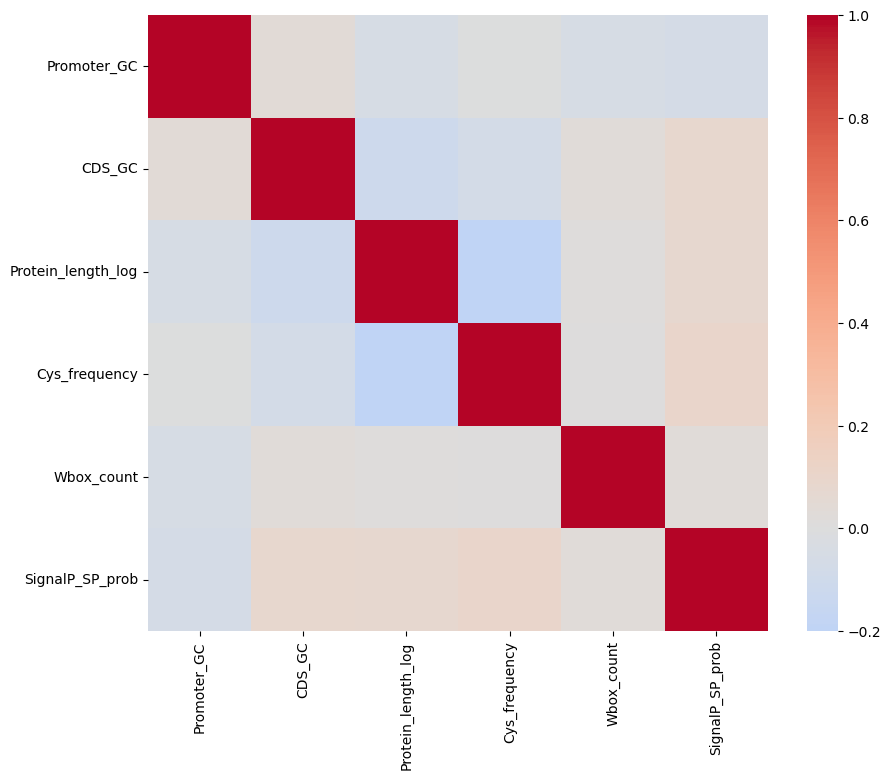

In [123]:
#feature correlation check
corr = df[feature_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

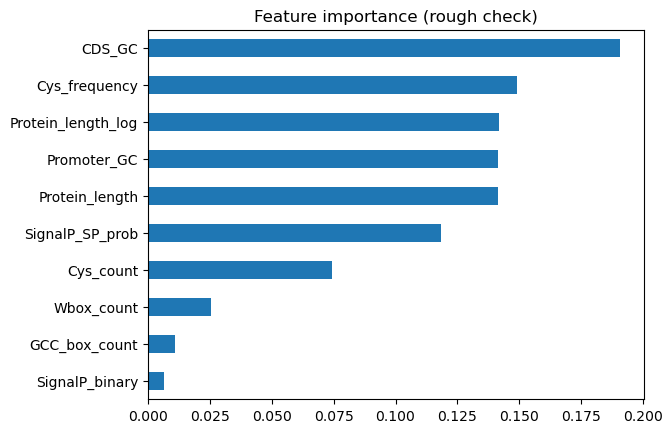

In [112]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200)

clf.fit(df[feature_cols], df["Label"])

importance = pd.Series(clf.feature_importances_, index=feature_cols)

importance.sort_values().plot(kind="barh")
plt.title("Feature importance (rough check)")
plt.show()

In [113]:
df["Label"].value_counts()

Label
0    35417
1      386
Name: count, dtype: int64

In [114]:
#for the nan value that wew are getting for signal p p values in u test we nned to do this
#contengenvy table
import pandas as pd

table = pd.crosstab(df["Label"], df["SignalP_binary"])
print(table)

SignalP_binary    0.0   1.0
Label                      
0               31998  3310
1                 259   127


In [115]:
#compute odds ratio
from scipy.stats import fisher_exact

odds_ratio, p = fisher_exact(table)

print("Odds ratio:", odds_ratio)
print("p-value:", p)

Odds ratio: 4.740223261673413
p-value: 7.785401719136291e-37


In [116]:
#signal binary and signal prob has strong correltion so we will keep only one of them which is signal prob
df = df.drop(columns=["SignalP_binary"])

In [117]:
print(df.columns)

Index(['GeneID', 'Promoter_GC', 'Wbox_count', 'GCC_box_count', 'CDS_GC',
       'Protein_length', 'Cys_count', 'Cys_frequency', 'Protein_length_log',
       'SignalP_SP_prob', 'Label', 'PU_score', 'PU_std', 'Promoter_AT',
       'Small_protein', 'SignalP_confidence', 'Cys_density_scaled',
       'Motif_density'],
      dtype='object')


In [120]:
#check i f anything is broken
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Cys_frequency",
    "Wbox_count",
    "SignalP_SP_prob"
]

In [121]:
X = df[feature_cols]

print(X.head())
print(X.shape)

   Promoter_GC    CDS_GC  Protein_length_log  Cys_frequency  Wbox_count  \
0        0.386  0.431010            6.555357       0.024217         0.0   
1        0.399  0.599068            4.962845       0.035211         0.0   
2        0.528  0.664198            5.598422       0.033457         0.0   
3        0.488  0.593715            6.386879       0.003373         0.0   
4        0.433  0.670940            4.356709       0.077922         1.0   

   SignalP_SP_prob  
0         0.000000  
1         0.000208  
2         0.000001  
3         0.772388  
4         0.000047  
(35803, 6)


In [124]:
#adding one more feature 
df["Small_protein"] = (df["Protein_length"] < 250).astype(int)

In [125]:
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Cys_frequency",
    "Wbox_count",
    "SignalP_SP_prob",
    "Small_protein"
]

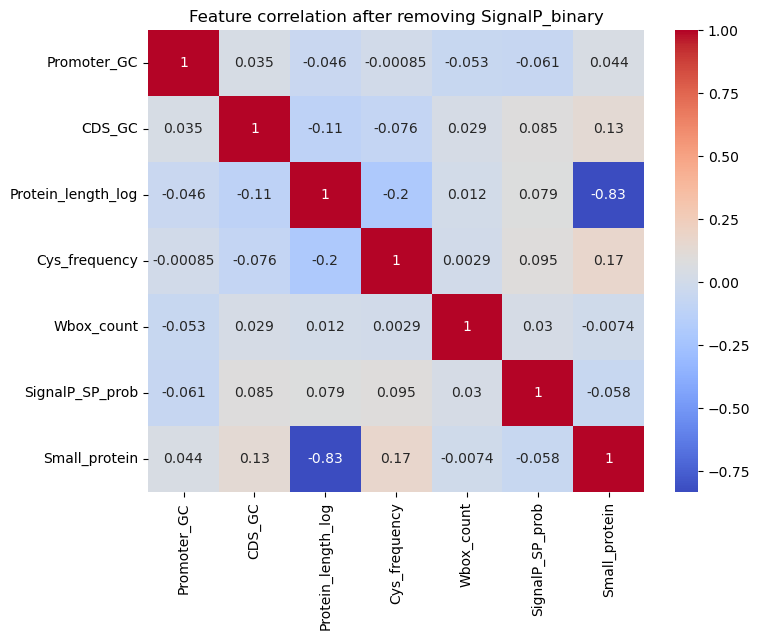

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[feature_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature correlation after removing SignalP_binary")
plt.show()

In [127]:
#remove small proetin cuz it has high correlation with protein lenghth log
# remove redundant feature
df = df.drop(columns=["Small_protein"], errors="ignore")

# verify
print(df.columns)

Index(['GeneID', 'Promoter_GC', 'Wbox_count', 'GCC_box_count', 'CDS_GC',
       'Protein_length', 'Cys_count', 'Cys_frequency', 'Protein_length_log',
       'SignalP_SP_prob', 'Label', 'PU_score', 'PU_std', 'Promoter_AT',
       'SignalP_confidence', 'Cys_density_scaled', 'Motif_density'],
      dtype='object')


In [128]:
# remove redundant feature
df = df.drop(columns=["Small_protein"], errors="ignore")

# verify
print(df.columns)

Index(['GeneID', 'Promoter_GC', 'Wbox_count', 'GCC_box_count', 'CDS_GC',
       'Protein_length', 'Cys_count', 'Cys_frequency', 'Protein_length_log',
       'SignalP_SP_prob', 'Label', 'PU_score', 'PU_std', 'Promoter_AT',
       'SignalP_confidence', 'Cys_density_scaled', 'Motif_density'],
      dtype='object')


In [131]:
feature_cols = [
    "Promoter_GC",
    "CDS_GC",
    "Protein_length_log",
    "Cys_frequency",
    "Wbox_count",
    "SignalP_SP_prob"
]

In [132]:
X = df[feature_cols]
y = df["Label"]

print(X.head())
print(X.shape)

   Promoter_GC    CDS_GC  Protein_length_log  Cys_frequency  Wbox_count  \
0        0.386  0.431010            6.555357       0.024217         0.0   
1        0.399  0.599068            4.962845       0.035211         0.0   
2        0.528  0.664198            5.598422       0.033457         0.0   
3        0.488  0.593715            6.386879       0.003373         0.0   
4        0.433  0.670940            4.356709       0.077922         1.0   

   SignalP_SP_prob  
0         0.000000  
1         0.000208  
2         0.000001  
3         0.772388  
4         0.000047  
(35803, 6)


In [133]:
#mutual information test that tells how much info each feature gives about the label
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print(mi_results)

ValueError: Input X contains NaN.

In [ ]:
#Your error happened because mutual_info_classif() cannot handle NaN values in the feature matrix. Somewhere in X there are missing values.

In [135]:
#first check where the NANs are
X.isna().sum()

Promoter_GC             0
CDS_GC                  0
Protein_length_log      0
Cys_frequency           0
Wbox_count              0
SignalP_SP_prob       217
dtype: int64

In [136]:
#fill these nans w zeros
X = X.fillna(0)

In [137]:
#now run mutual info again
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(mi_results)

SignalP_SP_prob       0.002336
CDS_GC                0.002322
Wbox_count            0.002045
Protein_length_log    0.001393
Cys_frequency         0.001300
Promoter_GC           0.000812
dtype: float64


In [138]:
#run quick random forest feature importance check
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importance)

CDS_GC                0.237381
Protein_length_log    0.199441
Promoter_GC           0.183166
SignalP_SP_prob       0.179374
Cys_frequency         0.163434
Wbox_count            0.037205
dtype: float64


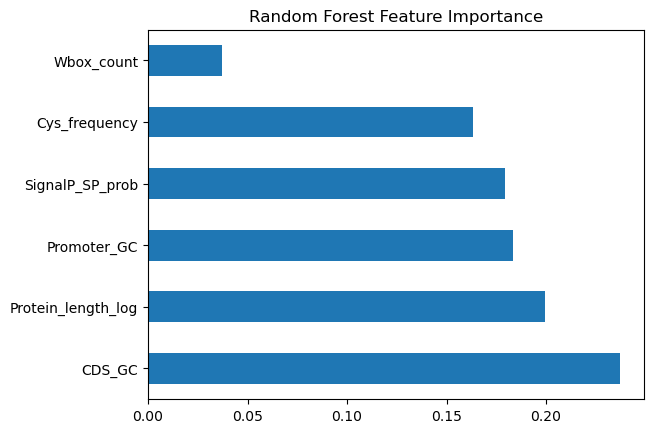

In [139]:
#visualisee it 
import matplotlib.pyplot as plt

importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()